In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from metocean_api import ts
import cdsapi
import datetime
%matplotlib inline
from scipy.stats import genextreme as gev
from scipy.signal import find_peaks
import xarray as xr
from pyextremes import plot_parameter_stability
from pyextremes.plotting import plot_extremes
from pyextremes import EVA
from pyextremes import get_extremes
from pyextremes import plot_threshold_stability
import scipy.stats as stats
from scipy.stats import weibull_min
import os


In [2]:
# Path to file
parent_dir = os.path.dirname(os.getcwd())
filename = os.path.join(parent_dir, 'Data', '2.595.0-Vannføring-inst-v1.csv')
print(filename)
# Read with the correct column name
df = pd.read_csv(
    filename,
    delimiter=';',                 # Specify the delimiter
    parse_dates=['Tidspunkt'],       # Use 'time' instead of 'timestamp'
    index_col='Tidspunkt',         # Set 'time' as the index
    skiprows=1            
)


df.columns = ['discharge', 'discharge_2', 'discharge_3']
df.drop(columns=['discharge_2', 'discharge_3'], inplace=True)
pd.to_numeric(
    df["discharge"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)






c:\Users\joppe\OneDrive\Civiel_master\MORE\Project\CEGM2005_glommaproject\Data\2.595.0-Vannføring-inst-v1.csv


Tidspunkt
1993-01-01 11:00:00+00:00     6.890178
1993-01-02 11:00:00+00:00     6.199734
1993-01-03 11:00:00+00:00     6.000031
1993-01-04 11:00:00+00:00     5.809420
1993-01-05 11:00:00+00:00     5.529519
                               ...    
2025-11-21 05:00:00+00:00    15.582570
2025-11-21 06:00:00+00:00    16.175540
2025-11-21 07:00:00+00:00    16.032110
2025-11-21 08:00:00+00:00    16.003190
2025-11-21 09:00:00+00:00    16.112070
Name: discharge, Length: 209860, dtype: float64

In [3]:
df = pd.read_csv(
    filename,
    sep=";",
    skiprows=2,  # skip comment + header
    names=["Tidspunkt", "discharge", "korrigert", "kontrollert"],
    usecols=[0, 1],               # alleen tijd + discharge
    parse_dates=["Tidspunkt"],
    index_col="Tidspunkt",
    decimal=",",                  # <-- dit is de key
)

print(df.dtypes)  # discharge moet float64 zijn


discharge    float64
dtype: object


In [4]:
data = df['discharge']

c:\Users\joppe\miniconda3\envs\mude-base\Lib\site-packages\pyextremes\eva.py:131: RuntimeWarning: 4,678 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)
c:\Users\joppe\miniconda3\envs\mude-base\Lib\site-packages\pyextremes\extremes\block_maxima.py:138: NoDataBlockWarning: 2 blocks contained no data
  warnings.warn(


Timestamps of found extremes:
DatetimeIndex(['1993-07-13 11:00:00+00:00', '1994-06-30 11:00:00+00:00',
               '1995-06-02 11:00:00+00:00', '1996-08-28 11:00:00+00:00',
               '1997-07-03 11:00:00+00:00', '1998-06-29 11:00:00+00:00',
               '1999-06-29 13:00:00+00:00', '2000-05-18 02:00:00+00:00',
               '2003-06-06 00:00:00+00:00', '2004-11-28 04:00:00+00:00',
               '2005-03-20 13:00:00+00:00', '2006-08-16 05:00:00+00:00',
               '2007-07-05 20:00:00+00:00', '2008-06-04 02:00:00+00:00',
               '2009-07-31 13:00:00+00:00', '2010-10-07 06:00:00+00:00',
               '2011-06-11 13:00:00+00:00', '2012-12-14 06:00:00+00:00',
               '2013-05-23 01:00:00+00:00', '2014-05-25 01:00:00+00:00',
               '2015-07-06 22:00:00+00:00', '2016-06-27 04:00:00+00:00',
               '2017-06-10 20:00:00+00:00', '2018-05-11 09:00:00+00:00',
               '2019-05-23 02:00:00+00:00', '2020-06-22 08:00:00+00:00',
               '2021-

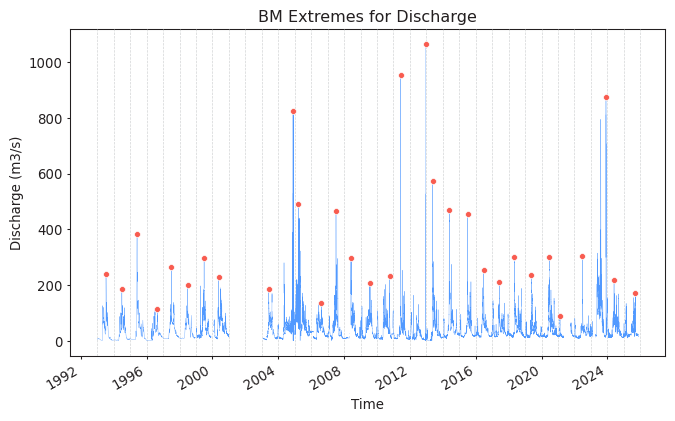

In [5]:
## BM Wind

data_bm = data  #.loc[:'2024-12-30']   ## Here the data is adjusted, to eliminate a low extreme. This is because january 1st of 2025 is part of the dataset as well and this would give an extra extreme, which is not representative.
model = EVA(data=data_bm)
model.get_extremes(
    method="BM",
    extremes_type="high",
    block_size="365.2540D",
    errors="ignore"
    )
#Plotting them
plot_extremes(
    ts=data,
    extremes = model.extremes,
    extremes_method="BM",
    extremes_type="high",
    block_size="365.2540D",
    )


# Print the timestamps of all found extremes
print("Timestamps of found extremes:");
print(model.extremes.index)
plt.title('BM Extremes for Discharge')
plt.xlabel('Time')
plt.ylabel('Discharge (m3/s)')
plt.show();

In [6]:
#Fitting the distribution and printing the fitting features
model.fit_model(
    model = "Emcee",
    distribution = "genextreme")
print(model.model)

# The genextreme distribution is the Generalized Extreme Value (GEV) distribution.
# It is used to model the distribution of block maxima (or minima) of samples of random variables.
# The GEV distribution combines the Gumbel, Fréchet, and Weibull families into a single family.
print("The genextreme distribution is the Generalized Extreme Value (GEV) distribution, commonly used for modeling the distribution of block maxima in extreme value theory.")

                     Emcee model                     
-----------------------------------------------------
free parameters: c=-0.340, loc=235.983, scale=123.175
fixed parameters: all parameters are free            
AIC: 415.500                                         
loglikelihood: -204.305                              
number of walkers: 100                               
number of samples: 500                               
return value cache size: 0                           
-----------------------------------------------------
The genextreme distribution is the Generalized Extreme Value (GEV) distribution, commonly used for modeling the distribution of block maxima in extreme value theory.


Number of extremes identified: 31


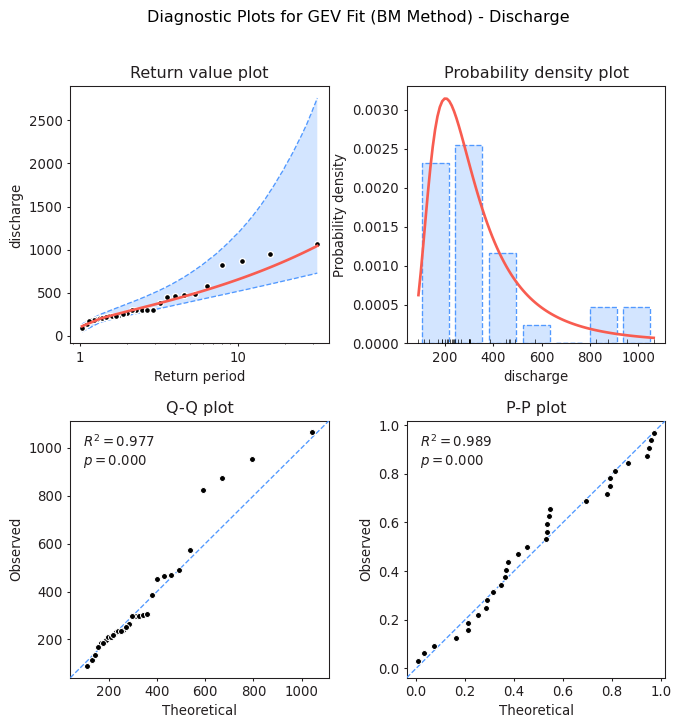

In [7]:
# Print the number of extremes identified
print(f"Number of extremes identified: {len(model.extremes)}")
#Assessing goodness of fit
model.plot_diagnostic(alpha=0.95)
plt.suptitle('Diagnostic Plots for GEV Fit (BM Method) - Discharge')
plt.show()


TypeError: EVA.get_return_value() missing 1 required positional argument: 'return_period'